# 17 — Diffusion models

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *How does noising data relate to the heat equation, and what must be learned to run the process backwards?*

A diffusion model generates data by **running a stochastic differential equation backwards in time**. Almost every ingredient is classical: the heat equation ([Fourier, 1822](https://digitalcollections.hkust.edu.hk/Detail/objects/b458351)), Brownian motion ([Einstein, 1905](https://doi.org/10.1002/andp.19053220806); [Wiener, 1923](https://doi.org/10.1002/sapm192321131)), the Feynman–Kac formula ([Kac, 1949](https://doi.org/10.1090/S0002-9947-1949-0027960-X)), and the time reversal of diffusions ([Anderson, 1982](https://doi.org/10.1016/0304-4149(82)90051-5)). The learning ingredient is that the single object the reversal needs — the **score** $\nabla \log p_t$ — can be learned from samples alone ([Hyvärinen, 2005](https://jmlr.org/papers/v6/hyvarinen05a.html); [Vincent, 2011](https://doi.org/10.1162/NECO_a_00142); [Song and Ermon, 2019](https://arxiv.org/abs/1907.05600); [Ho et al., 2020](https://arxiv.org/abs/2006.11239)).

### Table of Contents

1. **The forward process** — an Ornstein–Uhlenbeck process: Brownian noise, the heat equation, and a pull to $\mathcal{N}(0,I)$
2. **Reversing time** — Anderson's reverse-time SDE
3. **Score matching** — Hyvärinen's identity
4. **An analytically solvable example** — the lemniscate of Bernoulli: Tweedie's formula and sampling with the exact score
5. **Denoising score matching** — learning the score by regressing on noise
6. **A small diffusion model on MNIST** — and an animation of the denoising

**Appendix A. Feynman–Kac** — the dictionary between PDEs and stochastic processes

In [1]:
%matplotlib inline
import gzip, pathlib, urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

# Reproducibility
rng = np.random.default_rng(0)
torch.manual_seed(0);

## Where are we?

> **Recap.** [Notebook 16](16_neural_transport.ipynb): a neural ODE transports a probability density deterministically — the trajectories are the characteristics of a transport equation, and success is measured between laws, not between matched samples. [Notebook 07](07_adjoints_density_heat_control.ipynb): the heat equation, its smoothing, and its control.

This notebook makes the transport **stochastic**. The forward process dissolves data into noise — its density solves a heat-type equation — and generation runs the process backwards in time, which requires exactly one unknown object, the score $\nabla\log p_t$, learned from samples.

## 1. The forward process (noising data)

**Idea.** Brownian noise smooths the data distribution; a restoring drift makes it converge to a Gaussian.

Take a data point $X_0 \sim p_{\text{data}}$ in $\mathbb{R}^d$ and let it evolve by the forward SDE

$$dX_t = -\tfrac{1}{2} X_t\, dt + dW_t, \qquad X_0 \sim p_{\text{data}} .$$

The Brownian increment $dW_t$ adds noise; the drift $-X_t/2$ pulls back towards the origin, so the variance does not grow without bound and there is a stationary law to start the reverse process from. This is an **Ornstein–Uhlenbeck process**.

Because the equation is linear, variation of constants gives the solution in closed form,

$$X_t = e^{-t/2} X_0 + \int_0^t e^{-(t-s)/2}\, dW_s \;, \qquad X_t \mid X_0 \sim \mathcal{N}\!\big(\alpha_t X_0,\; \sigma_t^2 I\big), \qquad
\alpha_t = e^{-t/2}, \quad \sigma_t^2 = 1 - e^{-t},$$

where the variance follows from the Itô isometry, $\int_0^t e^{-(t-s)}ds = 1-e^{-t}$. 

In particular, **no simulation is needed to noise data**: $x_t = \alpha_t x_0 + \sigma_t \varepsilon$ with $\varepsilon\sim\mathcal{N}(0,I)$ jumps directly to any noise level, which is what makes training cheap.

In [2]:
alpha = lambda t: torch.exp(-t / 2)               # signal coefficient
img = 2 * torch.tensor(plt.imread("images/pontryagin.png"))[::4, ::4] - 1    # a grey-scale picture, pixels in [-1, 1]
ts = torch.cat([torch.zeros(1), torch.logspace(-2.5, np.log10(3.0), 30)])
tau = torch.expm1(ts)                                                        # heat time tau(t) = e^t - 1
dB = tau.diff().sqrt().reshape(-1, 1, 1) * torch.randn(30, *img.shape)
B = torch.cat([torch.zeros(1, *img.shape), torch.cumsum(dB, 0)])             # one Brownian path per pixel, at times tau(t)
P.animate_images(alpha(ts).reshape(-1, 1, 1) * (img + B), cmap="gray", vmin=-1, vmax=1, figsize=(2.6, 3.1),
                 title=lambda k: f"$X_t = \\alpha_t (X_0 + B_{{\\tau(t)}})$,  $t = {ts[k]:.2f}$")

### 1.2 The density solves a heat equation

The lemma turns the density of $X_t$ into a rescaled heat-equation solution. $X_0 + B_\tau$ has the density $u(\cdot,\tau) = k_\tau * p_{\text{data}}$, where the Gaussian kernel $k_\tau(z) = (2\pi \tau)^{-d/2} e^{-|z|^2/(2\tau)}$ satisfies $\partial_\tau k_\tau = \tfrac12\Delta k_\tau$. Hence

$$\boxed{\;p_t(x) = \alpha_t^{-d}\, u\big(x/\alpha_t,\ \tau(t)\big), \qquad \partial_\tau u = \tfrac12 \Delta u, \quad u(\cdot,0) = p_{\text{data}}.\;}$$

**Adding noise to data is the heat equation run forward on the data density**, read in rescaled coordinates.

In Fourier variables $\hat p_t(\xi) = \hat p_{\text{data}}(\alpha_t \xi)\, e^{-\sigma_t^2|\xi|^2/2}$: fine detail is destroyed first, exponentially fast in $|\xi|^2$. That is what the picture above shows — edges and texture vanish long before the silhouette.

> **Lemma.**
> The same statement in the original coordinates is the **Fokker–Planck equation**. Here
> 
> $$\partial_t p_t = \underbrace{\nabla\!\cdot\!\big(\tfrac{x}{2}\,p_t\big)}_{\text{pull to the origin}} + \underbrace{\tfrac12 \Delta p_t}_{\text{heat equation}} .$$
>
> The stationary density solves $\tfrac{x}{2}p + \tfrac12\nabla p = 0$, i.e. $\nabla \log p = -x$: the **standard Gaussian** $\mathcal{N}(0, I)$.

In [3]:
sigma = lambda t: torch.sqrt(-torch.expm1(-t))    # noise level sqrt(1 - e^{-t}); expm1 is stable as t -> 0
g = torch.linspace(-3, 3, 41)
X1, X2 = torch.meshgrid(g, g, indexing="xy")
mu, s2 = torch.tensor([[-1.5, -1.0], [1.5, -1.0], [0.0, 1.5]]), 0.1     # p_0: three narrow Gaussian bumps

def density(t):
    """p_t: each bump N(mu, s2 I) becomes N(alpha_t mu, (alpha_t^2 s2 + sigma_t^2) I)."""
    v = alpha(t) ** 2 * s2 + sigma(t) ** 2
    d2 = (X1[..., None] - alpha(t) * mu[:, 0]) ** 2 + (X2[..., None] - alpha(t) * mu[:, 1]) ** 2
    return (torch.exp(-d2 / (2 * v)) / (2 * np.pi * v)).mean(-1)

ts = torch.cat([torch.zeros(1), torch.logspace(-2, np.log10(8.0), 30)])
P.animate_surface(X1, X2, [density(t) for t in ts], title=lambda k: f"$p_t$,  $t = {ts[k]:.2f}$")

Generation is the *inverse* problem: from $p_T \approx$ noise, recover $p_0$. The backward heat equation is the textbook example of an **ill-posed** problem — the amplification factor $e^{+\tau|\xi|^2/2}$ turns any perturbation into an explosion. The trick of diffusion models is *not* to reverse the PDE. It is to reverse the **stochastic process**, which, as we will see, is perfectly well posed provided we know one extra object: $\nabla \log p_t$.

## 2. Reversing time


We now have a process that turns data into noise. We want the opposite. Everything below follows from one equation and one identity. The equation is the **Fokker–Planck equation** of the forward SDE (the same equation as in the lemma of §1.2). Then

$$
\begin{aligned}
\partial_t p_t &= \nabla\!\cdot\!\big(\tfrac{x}{2}\,p_t\big) + \tfrac12\Delta p_t  \\
&= \nabla\!\cdot\!\big(\tfrac{x}{2}\,p_t\big) + \tfrac12\nabla\!\cdot\!\big(p_t\,\nabla\log p_t\big) && \big( \Delta p = \nabla\!\cdot(p\,\nabla\log p)\big) \\
&= \nabla\!\cdot\!\Big[\tfrac12\big(x + \nabla\log p_t\big)\,p_t\Big].
\end{aligned}
$$

To run time backwards, set $s = T - t$ and write $q_s = p_{T-s}$. Then

$$
\begin{aligned}
\partial_s q_s &= -\big(\partial_t p_t\big)\big|_{t = T-s} \\
&= -\nabla\!\cdot\!\Big[\tfrac12\big(x + \nabla\log q_s\big)\,q_s\Big].
\end{aligned}
$$

> **Proposition (reverse-time family).** Let $\lambda \ge 0$, let $B$ be a Brownian motion, and let $Y$ solve
>
> $$dY_s = \Big[\tfrac12 Y_s + \tfrac{1+\lambda^2}{2}\,\nabla \log p_{T-s}(Y_s)\Big] ds + \lambda\, dB_s, \qquad Y_0 \sim p_T, \quad 0 \le s \le T .$$
>
> Then $Y_s \sim p_{T-s}$ for every $s$.

*Proof.* $Y$ has drift $b(y,s) = \tfrac12 y + \tfrac{1+\lambda^2}{2}\nabla\log q_s(y)$ and noise $\lambda\, dB$, so its law $\rho_s$ solves

$$\partial_s \rho_s = -\nabla\!\cdot\!\big(b\,\rho_s\big) + \tfrac{\lambda^2}{2}\Delta\rho_s, \qquad \rho_0 = p_T .$$

We check that $q$ solves the same equation:

$$
\begin{aligned}
-\nabla\!\cdot\!\big(b\,q_s\big) + \tfrac{\lambda^2}{2}\Delta q_s
&= -\nabla\!\cdot\!\Big[\big(\tfrac12 x + \tfrac{1+\lambda^2}{2}\nabla\log q_s\big)\,q_s\Big] + \nabla\!\cdot\!\Big[\tfrac{\lambda^2}{2}\,q_s\nabla\log q_s\Big] && \big(\Delta q = \nabla\!\cdot(q\,\nabla\log q)\big) \\
&= -\nabla\!\cdot\!\Big[\tfrac12\big(x + \nabla\log q_s\big)\,q_s\Big] && (\lambda^2 \text{ terms cancel}) \\
&= \partial_s q_s && \text{(reversed transport equation)}.
\end{aligned}
$$

Since also $q_0 = p_T = \rho_0$, uniqueness for this Fokker–Planck equation (granted enough regularity of the score) gives $\rho_s = q_s$. $\square$

<!-- The noise $\lambda\, dB$ spreads mass at rate $\tfrac{\lambda^2}{2}\Delta$, and the extra drift $\tfrac{\lambda^2}{2}\nabla\log p$ undoes exactly that spreading. $\lambda = 1$, with drift $\tfrac12 Y + \nabla\log p_{T-s}(Y)$, is **Anderson's reverse-time SDE** ([Anderson, 1982](https://doi.org/10.1016/0304-4149(82)90051-5)). $\lambda = 0$ removes the noise altogether and leaves a deterministic ODE with the same marginals, the **probability-flow ODE** (the family is from [Song et al., 2021](https://arxiv.org/abs/2011.13456)). -->

Everything is explicit except the **score** $s(x,t):=\nabla \log p_t$. That is the entire learning problem. 

## 3. Score matching ([Hyvärinen, 2005](https://jmlr.org/papers/v6/hyvarinen05a.html))

We need $s(x,t) = \nabla \log p_t(x)$, but we only ever see *samples* from $p_t$, never its density. The obvious objective is useless as written, since it needs the unknown $\nabla \log p$:

$$J(\theta) = \tfrac12\, \mathbb{E}_{x \sim p}\big\|s_\theta(x) - \nabla \log p(x)\big\|^2 .$$

Expand the square and integrate the cross term by parts, using $p \nabla \log p = \nabla p$ and assuming $p\, s_\theta \to 0$ at infinity:

$$-\mathbb{E}_p\big[s_\theta \cdot \nabla \log p\big] = -\int s_\theta \cdot \nabla p \,dx = \int (\nabla\!\cdot\! s_\theta)\, p\, dx .$$

Hence, up to a constant independent of $\theta$,

$$J(\theta) = \mathbb{E}_{x\sim p}\Big[\tfrac12 \|s_\theta(x)\|^2 + \nabla\!\cdot\! s_\theta(x)\Big] + \text{const}.$$

The unknown density has **disappeared**: the objective is a plain sample average. The catch is the divergence $\nabla\cdot s_\theta = \sum_i \partial_i s_\theta^i$, which costs $d$ backward passes per training step — already hopeless at the $d = 784$ of a $28\times28$ image.

The way out uses the special structure of $p_t$, a Gaussian smoothing of the data. It is easiest to see on an example where the score is known in closed form.

## 4. A problem we can solve by hand: the lemniscate

**Idea.** Test the sampler on a small dataset whose score is explicit.

Take as data the empirical measure of $N$ training points, $p_{\text{data}} = \frac1N \sum_i \delta_{x_i}$. Since $X_t \mid X_0 = x_i \sim \mathcal{N}(\alpha_t x_i, \sigma_t^2 I)$, the density $p_t$ is a mixture of $N$ isotropic Gaussians, and by Bayes (uniform prior) the posterior probability of the $i$-th training point is

$$w_i(x,t) = \mathbb{P}(X_0 = x_i \mid X_t = x) = \operatorname{softmax}_i\!\left(-\frac{\|x - \alpha_t x_i\|^2}{2\sigma_t^2}\right).$$

Differentiating $\log p_t$ gives the score as the posterior-weighted average of the component scores:

$$
\begin{aligned}
\nabla \log p_t(x) &= -\frac{1}{\sigma_t^2} \sum_{i=1}^N w_i(x,t)\,\big(x - \alpha_t x_i\big) \\
&= -\frac{1}{\sigma_t^2}\, \mathbb{E}\big[\, X_t - \alpha_t X_0 \mid X_t = x \,\big] \\
&= -\frac{1}{\sigma_t}\, \mathbb{E}\big[\, \varepsilon \mid X_t = x \,\big] && \big(X_t - \alpha_t X_0 = \sigma_t \varepsilon\big).
\end{aligned}
$$

Nothing here used that $p_{\text{data}}$ is discrete: with the sum replaced by an integral, the same computation holds for any data distribution. This is **Tweedie's formula** ([Robbins, 1956](https://digicoll.lib.berkeley.edu/record/112828); [Efron, 2011](https://doi.org/10.1198/jasa.2011.tm11181)): up to the factor $-1/\sigma_t$, the score is the best guess of the **noise** that was added. It is equally the best guess of the **clean data**: given $X_t = x$, $x$ leaves the expectation, and solving the second line for $\mathbb{E}[X_0 \mid X_t = x]$ gives the **optimal denoiser**

$$\hat x_0(x,t) \;:=\; \mathbb{E}[X_0 \mid X_t = x] \;=\; \frac{x + \sigma_t^2\, \nabla\log p_t(x)}{\alpha_t} \;=\; \sum_{i=1}^N w_i(x,t)\, x_i ,$$

here a **soft nearest neighbor** among the training points at temperature $\sigma_t^2$. *Learning to score is learning to denoise.* As $\sigma_t \to 0$ the weights concentrate on a single training point, so the exact score drives samples onto the training set. The animation noises $8$ copies of each training point with the forward process, then runs Anderson's reverse SDE ($\lambda = 1$ in §2) with this exact score from where the noising ended, and finishes with one denoising step $\hat x_0$.

In [4]:
T, T_MIN = 8.0, 1e-3   # horizon (alpha_T = 0.018, so p_T ≈ N(0, I)) and smallest noise level (sigma = 0.032)

def diffuse(x0, t, eps=None):
    """One-step forward noising: x_t = alpha_t x_0 + sigma_t eps, exact for any t."""
    eps = torch.randn_like(x0) if eps is None else eps
    shape = (-1,) + (1,) * (x0.dim() - 1)             # broadcast t over sample dimensions
    return alpha(t).reshape(shape) * x0 + sigma(t).reshape(shape) * eps

def lemniscate(n, a=1.6):
    """Sample n points on Bernoulli's lemniscate (x1^2+x2^2)^2 = a^2 (x1^2-x2^2)."""
    tau = 2 * np.pi * torch.rand(n)
    d = 1 + torch.sin(tau) ** 2
    return torch.stack([a * torch.cos(tau) / d, a * torch.sin(tau) * torch.cos(tau) / d], dim=1)

X_data = lemniscate(128)            # the training set: deliberately small, so we can see what it does
X_curve = lemniscate(20000)         # a dense reference for "the lemniscate itself"

In [5]:
@torch.no_grad()
def reverse_sample(score, x, ts):
    """Euler-Maruyama for Anderson's reverse SDE  dx = [x/2 + score] ds + dB,  along the decreasing grid ts."""
    traj = [x]
    for i in range(len(ts) - 1):
        t, h = ts[i], ts[i] - ts[i + 1]
        x = x + h * (0.5 * x + score(x, t))
        if i < len(ts) - 2:                              # no noise on the very last step
            x = x + h.sqrt() * torch.randn_like(x)
        traj.append(x)
    return torch.stack(traj)

def time_grid(n, t_min=T_MIN):
    """Geometric grid T = t_0 > ... > t_{n-1} = t_min: small steps near t = 0, where the score is stiff."""
    return torch.logspace(np.log10(T), np.log10(t_min), n)

@torch.no_grad()
def denoise(score, x, t):
    """Tweedie's formula: the posterior mean E[x_0 | x_t = x]."""
    return (x + sigma(t) ** 2 * score(x, t)) / alpha(t)

def exact_score(x, t):
    """Exact score of p_t when p_data is the empirical measure of X_data (a Gaussian mixture)."""
    d = x[:, None, :] - alpha(t) * X_data[None, :, :]                  # (B, N, 2)
    w = torch.softmax(-(d ** 2).sum(-1) / (2 * sigma(t) ** 2), dim=1)  # soft nearest neighbour
    return -(w[:, :, None] * d).sum(1) / sigma(t) ** 2

In [6]:
torch.manual_seed(1)
x0, eps = X_data.repeat(8, 1), torch.randn(1024, 2)             # 8 copies of each training point
t_up = time_grid(30).flip(0)                                     # T_MIN -> T
noising = torch.stack([diffuse(x0, t, eps) for t in t_up])

ts_2d = time_grid(400)
traj = reverse_sample(exact_score, noising[-1], ts_2d)          # start where the noising ended
idx = torch.linspace(0, len(ts_2d) - 1, 40).long()
x_hat = denoise(exact_score, traj[-1], ts_2d[-1])

film = torch.cat([noising, traj[idx], x_hat.repeat(8, 1, 1)])    # hold the last frame
times = torch.cat([t_up, ts_2d[idx]])
P.animate_points(film, background=X_curve, s=4, figsize=(4.2, 3.7),
                 xlabel="$x_1$", ylabel="$x_2$", xlim=(-3.2, 3.2), ylim=(-3.2, 3.2),
                 title=lambda k: f"noising,  $t = {times[k]:.3f}$" if k < len(t_up) else
                                 f"reverse SDE,  $t = {times[k]:.3f}$" if k < len(times) else
                                 "denoised: $\\hat x_0$")

## 5. Denoising score matching ([Vincent, 2011](https://doi.org/10.1162/NECO_a_00142))

Tweedie's formula (§4) expresses the score as a conditional expectation, and a conditional expectation is exactly what least-squares regression computes: $\mathbb{E}[Y \mid X]$ minimizes $\mathbb{E}\|h(X) - Y\|^2$ over all measurable $h$. Since we *generate* the noise $\varepsilon$ ourselves, we know the regression target. Minimize over $\theta$

$$\boxed{\;\mathcal{L}(\theta) = \mathbb{E}_{t \sim \pi}\; \mathbb{E}_{x_0 \sim p_{\text{data}}}\; \mathbb{E}_{\varepsilon \sim \mathcal{N}(0,I)} \;\big\| \varepsilon_\theta\big(\alpha_t x_0 + \sigma_t \varepsilon,\; t\big) - \varepsilon \big\|^2 \;}$$

whose minimizer is $\varepsilon_\theta^\star(x,t) = \mathbb{E}[\varepsilon \mid X_t = x] = -\sigma_t \nabla \log p_t(x)$. We then set

$$s_\theta(x,t) = -\,\frac{\varepsilon_\theta(x,t)}{\sigma_t}, \qquad \hat x_0(x,t) = \frac{x - \sigma_t\,\varepsilon_\theta(x,t)}{\alpha_t}.$$

This is the DDPM loss of [Ho et al. (2020)](https://arxiv.org/abs/2006.11239). Three lines of code, no divergence, no density, and no simulation of the forward SDE. 

### 5.1 Learning the lemniscate's score

We now forget the closed form and learn the score of §4 from the 128 points alone. The network is a small MLP in $(x, t)$, told the time through the log signal-to-noise ratio $\log(\alpha_t^2/\sigma_t^2)$. Training times are drawn log-uniformly on $[T_{\min}, T]$, the range the sampler integrates over.

In [7]:
log_snr = lambda t: 2 * torch.log(alpha(t) / sigma(t))   # log signal-to-noise ratio

class TimeEmbedding(nn.Module):
    """Turn the noise level into a vector: the log-SNR, rescaled, through a small MLP."""
    def __init__(self, dim=32):
        super().__init__()
        self.dim = dim
        self.net = nn.Sequential(nn.Linear(1, dim), nn.SiLU(), nn.Linear(dim, dim))
    def forward(self, t, n):
        return self.net((log_snr(t) / 8).reshape(-1, 1).expand(n, 1))      # scalar t broadcasts

class ScoreNet(nn.Module):
    """Predicts the noise eps given (x, t); the score is then -eps_theta / sigma_t."""
    def __init__(self, dim=2, width=128):
        super().__init__()
        self.temb = TimeEmbedding()
        self.net = nn.Sequential(
            nn.Linear(dim + self.temb.dim, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, dim),
        )
    def forward(self, x, t):
        return self.net(torch.cat([x, self.temb(t, len(x))], dim=1))

def sample_times(n):
    """Log-uniform times on [T_MIN, T] -- the same range the sampler will integrate over."""
    return T_MIN * (T / T_MIN) ** torch.rand(n)

In [8]:
torch.manual_seed(0)
eps_theta = ScoreNet()
opt = torch.optim.Adam(eps_theta.parameters(), lr=3e-3)
STEPS = 6000
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=STEPS)

for it in range(STEPS):
    x0 = X_data[torch.randint(0, len(X_data), (256,))]      # a batch of data
    t = sample_times(256)                                   # a batch of noise levels
    eps = torch.randn_like(x0)                              # the regression target
    loss = ((eps_theta(diffuse(x0, t, eps), t) - eps) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()

learned_score = lambda x, t: -eps_theta(x, t) / sigma(t)

In [9]:
x_T = torch.randn(1024, 2)
films = []
for score in [exact_score, learned_score]:
    torch.manual_seed(2)                                        # the same Brownian increments for both
    traj = reverse_sample(score, x_T, ts_2d)
    films.append(torch.cat([traj[idx], denoise(score, traj[-1], ts_2d[-1]).repeat(8, 1, 1)]))

P.animate_point_panels(films, ["exact score", "learned score"], background=X_curve, marks=X_data,
                       xlim=(-2, 2), ylim=(-1.2, 1.2),
                       title=lambda k: f"reverse SDE,  $t = {ts_2d[idx[k]]:.3f}$" if k < len(idx) else
                                       "denoised: $\\hat x_0$  (black: the 128 training points)")

## 6. A small diffusion model on MNIST

**Idea.** Use the same loss and sampler with an image-shaped network.

Now $d = 784$ instead of $2$. The loss is the same and the sampler is *literally the same function*; only the network changes. The score of an image is roughly *local* (a pixel's noise is best estimated from its neighborhood) and acts at *all scales* (coarse layout at large $t$, fine texture at small $t$), so we use a small convolutional **U-Net**, with the time embedding of §5.1 added to every block.

We also **standardize** the pixels to mean $0$ and variance $1$, matching the stationary law $\mathcal{N}(0,I)$ the reverse process starts from. Otherwise the image-wide brightness is not yet forgotten at $t = T$, and the samples come out on a wrong background.

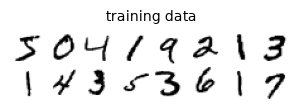

In [10]:
# MNIST: 60000 handwritten digits, 28 x 28, downloaded once into ./data
DATA = pathlib.Path("data"); DATA.mkdir(exist_ok=True)
gz = DATA / "mnist-train-images.gz"
if not gz.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz", gz)

raw = np.frombuffer(gzip.decompress(gz.read_bytes()), dtype=np.uint8, offset=16)
mnist = torch.tensor(raw.reshape(-1, 1, 28, 28).copy())          # uint8, converted per batch

# Standardize, so that p_data has the mean and variance of the stationary law N(0, I)
_pixels = mnist[:10000].float() / 127.5 - 1
MU, SD = _pixels.mean(), _pixels.std()
to_model = lambda u8: ((u8.float() / 127.5 - 1) - MU) / SD       # uint8 image  -> model coordinates
to_image = lambda x: x * SD + MU                                 # model coords -> [-1, 1] for display

P.show_images(mnist[:16].float() / 127.5 - 1, nrow=8, title="training data", figsize=(8, 1.2))
plt.show()

In [11]:
class Block(nn.Module):
    """Two convolutions with group norm, plus an additive time embedding."""
    def __init__(self, c_in, c_out, c_emb):
        super().__init__()
        self.conv1, self.conv2 = nn.Conv2d(c_in, c_out, 3, padding=1), nn.Conv2d(c_out, c_out, 3, padding=1)
        self.norm1, self.norm2 = nn.GroupNorm(8, c_out), nn.GroupNorm(8, c_out)
        self.emb = nn.Linear(c_emb, c_out)
    def forward(self, x, e):
        h = F.silu(self.norm1(self.conv1(x))) + self.emb(e)[:, :, None, None]
        return F.silu(self.norm2(self.conv2(h)))

class UNet(nn.Module):
    """Minimal three-scale U-Net: 28 -> 14 -> 7 -> 14 -> 28."""
    def __init__(self, c=16, c_emb=64):
        super().__init__()
        self.temb = TimeEmbedding(c_emb)                              # same module as in section 5
        self.down1, self.down2 = Block(1, c, c_emb), Block(c, 2 * c, c_emb)
        self.mid = Block(2 * c, 2 * c, c_emb)
        self.up2, self.up1 = Block(4 * c, c, c_emb), Block(2 * c, c, c_emb)
        self.out = nn.Conv2d(c, 1, 1)

    def forward(self, x, t):
        e = self.temb(t, len(x))
        h1 = self.down1(x, e)                                         # 28 x 28
        h2 = self.down2(F.avg_pool2d(h1, 2), e)                       # 14 x 14
        m = self.mid(F.avg_pool2d(h2, 2), e)                          #  7 x  7
        u = self.up2(torch.cat([F.interpolate(m, scale_factor=2), h2], dim=1), e)
        u = self.up1(torch.cat([F.interpolate(u, scale_factor=2), h1], dim=1), e)
        return self.out(u)

unet = UNet()
print(f"parameters: {sum(p.numel() for p in unet.parameters()):,}")

parameters: 65,393


In [12]:
STEPS, BATCH = 6000, 64
opt = torch.optim.Adam(unet.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=STEPS)

mnist_losses = []
for it in range(STEPS + 1):
    x0 = to_model(mnist[torch.randint(0, len(mnist), (BATCH,))])            # standardized batch
    t = sample_times(BATCH)
    eps = torch.randn_like(x0)
    loss = ((unet(diffuse(x0, t, eps), t) - eps) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    mnist_losses.append(loss.item())
    if it % 1000 == 0:
        print(f"iteration {it:5d}:  loss = {np.mean(mnist_losses[-200:]):.4f}")

iteration     0:  loss = 1.1114


iteration  1000:  loss = 0.0973


iteration  2000:  loss = 0.0903


iteration  3000:  loss = 0.0871


iteration  4000:  loss = 0.0853


iteration  5000:  loss = 0.0844


iteration  6000:  loss = 0.0832


### 6.1 Watching the denoising

The animation follows 16 trajectories of the reverse SDE, from pure noise to digits. Generation is **coarse-to-fine**, which is §1.2 read backwards: the heat equation destroys high frequencies first, so reversing it restores them last — the rough shape of each digit appears long before its strokes are sharp.

In [13]:
mnist_score = lambda x, t: -unet(x, t) / sigma(t)

ts_img = time_grid(300)
torch.manual_seed(3)
traj_img = reverse_sample(mnist_score, torch.randn(16, 1, 28, 28), ts_img)
digits = denoise(mnist_score, traj_img[-1], ts_img[-1])

idx = torch.linspace(0, len(ts_img) - 1, 32).long()
film = [P.image_grid(to_image(x).clamp(-1, 1), 8) for x in [*traj_img[idx], *[digits] * 6]]   # hold the last frame
P.animate_images(film, figsize=(8, 2.4),
                 title=lambda k: f"reverse SDE,  $t = {ts_img[idx[k]]:.3f}$" if k < len(idx) else "denoised")

## Key takeaways

- Adding Gaussian noise evolves the data distribution by a diffusion equation.
- The score is the gradient of the log density and determines the reverse drift.
- Denoising score matching learns the score by predicting noise we added ourselves.
- Exact fitting of the empirical distribution reproduces training points; generalization requires a useful model bias.

## Exercises

1. Take $p_{\text{data}} = \mathcal{N}(0, s^2 I)$. Show that $p_t = \mathcal{N}\big(0, (\alpha_t^2 s^2 + \sigma_t^2) I\big)$, so the score is linear and the reverse SDE is **linear**; solve it explicitly and verify numerically against `reverse_sample`.
2. Verify Hyvärinen's identity numerically in 1D: estimate $\mathbb{E}_p[\tfrac12\|s_\theta\|^2 + \partial_x s_\theta]$ by Monte Carlo for a Gaussian $p$ and compare with $J(\theta)$ computed in closed form.
3. Replace the geometric time grid by a uniform one at the same number of steps, and find where the 2-D sampler becomes unstable. Relate the threshold to $h \lesssim \sigma_t^2$.
4. Add the parameter $\lambda$ of §2 to `reverse_sample` and compare $\lambda = 0$ (the deterministic *probability-flow ODE*) with $\lambda = 1$ on MNIST at 30, 100 and 300 steps. Which degrades faster, and why?
5. Add class conditioning to the MNIST model (the labels are in `train-labels-idx1-ubyte.gz`) and implement classifier-free guidance by training with the label randomly dropped.

## Where are we going?

Diffusion models generate by reversing a stochastic flow, with the score as the one learned ingredient. [Notebook 18](18_reinforcement_learning.ipynb) closes the course's loop in a different way: the system itself is unknown, and the *control* is what gets learned, from rewards. [Notebook 19](19_synthesis_control_and_learning.ipynb) then collects the threads of the whole course and classifies each control ↔ learning connection by its scope.

## References

**The classical background**

- J. Fourier, [*Théorie analytique de la chaleur*](https://digitalcollections.hkust.edu.hk/Detail/objects/b458351), 1822 — the heat equation.
- A. Einstein, [*Über die von der molekularkinetischen Theorie der Wärme geforderte Bewegung von in ruhenden Flüssigkeiten suspendierten Teilchen*](https://doi.org/10.1002/andp.19053220806), *Annalen der Physik* **322** (1905), 549–560.
- M. von Smoluchowski, [*Zur kinetischen Theorie der Brownschen Molekularbewegung und der Suspensionen*](https://doi.org/10.1002/andp.19063261405), *Annalen der Physik* **326** (1906), 756–780.
- N. Wiener, [*Differential-Space*](https://doi.org/10.1002/sapm192321131), *Journal of Mathematics and Physics* **2** (1923), 131–174.
- A. N. Kolmogorov, [*Über die analytischen Methoden in der Wahrscheinlichkeitsrechnung*](https://doi.org/10.1007/BF01457949), *Mathematische Annalen* **104** (1931), 415–458.
- R. P. Feynman, [*Space-Time Approach to Non-Relativistic Quantum Mechanics*](https://doi.org/10.1103/RevModPhys.20.367), *Reviews of Modern Physics* **20** (1948), 367–387.
- M. Kac, [*On distributions of certain Wiener functionals*](https://doi.org/10.1090/S0002-9947-1949-0027960-X), *Transactions of the AMS* **65** (1949), 1–13.
- E. Schrödinger, [*Über die Umkehrung der Naturgesetze*](https://arxiv.org/abs/2105.12617), *Sitzungsberichte der Preussischen Akademie der Wissenschaften* (1931), 144–153; linked English translation.
- H. Föllmer, [*Random fields and diffusion processes*](https://doi.org/10.1007/BFb0086180), *Lecture Notes in Mathematics* **1362** (1988), 101–203.
- B. D. O. Anderson, [*Reverse-time diffusion equation models*](https://doi.org/10.1016/0304-4149(82)90051-5), *Stochastic Processes and their Applications* **12** (1982), 313–326.
- U. G. Haussmann and E. Pardoux, [*Time reversal of diffusions*](https://doi.org/10.1214/aop/1176992362), *Annals of Probability* **14** (1986), 1188–1205.
- H. Robbins, [*An empirical Bayes approach to statistics*](https://digicoll.lib.berkeley.edu/record/112828), *Proceedings of the Third Berkeley Symposium*, Vol. 1 (1956), 157–163.
- B. Efron, [*Tweedie’s formula and selection bias*](https://doi.org/10.1198/jasa.2011.tm11181), *JASA* **106** (2011), 1602–1614.

**Learning the score**

- A. Hyvärinen, [*Estimation of non-normalized statistical models by score matching*](https://jmlr.org/papers/v6/hyvarinen05a.html), *JMLR* **6** (2005), 695–709.
- P. Vincent, [*A connection between score matching and denoising autoencoders*](https://doi.org/10.1162/NECO_a_00142), *Neural Computation* **23** (2011), 1661–1674.

**Diffusion models and related methods**

- J. Sohl-Dickstein et al., [*Deep unsupervised learning using nonequilibrium thermodynamics*](https://arxiv.org/abs/1503.03585), ICML, 2015.
- Y. Song and S. Ermon, [*Generative modeling by estimating gradients of the data distribution*](https://arxiv.org/abs/1907.05600), NeurIPS, 2019.
- J. Ho, A. Jain and P. Abbeel, [*Denoising diffusion probabilistic models*](https://arxiv.org/abs/2006.11239), NeurIPS, 2020.
- Y. Song et al., [*Score-based generative modeling through stochastic differential equations*](https://arxiv.org/abs/2011.13456), ICLR, 2021.
- T. Karras et al., [*Elucidating the design space of diffusion-based generative models*](https://arxiv.org/abs/2206.00364), NeurIPS, 2022.
- V. De Bortoli et al., [*Diffusion Schrödinger bridge with applications to score-based generative modeling*](https://arxiv.org/abs/2106.01357), NeurIPS, 2021.
- Y. Lipman et al., [*Flow matching for generative modeling*](https://arxiv.org/abs/2210.02747), ICLR, 2023.
- S. Lin et al., [*Common diffusion noise schedules and sample steps are flawed*](https://arxiv.org/abs/2305.08891), WACV, 2024.
- R. T. Q. Chen et al., [*Neural ordinary differential equations*](https://arxiv.org/abs/1806.07366), NeurIPS, 2018.

## Appendix A. Feynman–Kac: the PDE / stochastic process dictionary

**Idea.** A PDE solution can be computed as an average over random paths.

The bridge between the two worlds has two directions.

**Forward (Kolmogorov forward / Fokker–Planck).** If $X_t$ solves $dX_t = f(X_t,t)\,dt + g(t)\,dW_t$, then its density evolves by

$$\partial_t p_t = -\nabla\!\cdot\!\big(f\,p_t\big) + \tfrac{g(t)^2}{2}\,\Delta p_t .$$

This is a statement about **densities**: it pushes the law of the particles forward.

**Backward (Feynman–Kac).** Fix a terminal payoff $\varphi$ and a potential $V$. Then

$$u(x,t) = \mathbb{E}\left[\, e^{-\int_t^T V(X_s)\,ds}\,\varphi(X_T) \;\middle|\; X_t = x \right]$$

solves the **linear** PDE

$$\partial_t u + f\cdot\nabla u + \tfrac{g^2}{2}\Delta u = V u, \qquad u(\cdot, T) = \varphi .$$

This is a statement about **observables**: the value of the PDE at $(x,t)$ is an average over all trajectories started at $x$.

Taking $f = 0$, $g = 1$, $V = 0$ and reversing time ($t \mapsto T-t$) gives the cleanest instance of the formula, the one we care about:

$$\partial_t u = \tfrac12 \Delta u, \quad u(\cdot,0) = u_0 \qquad \Longleftrightarrow \qquad u(x,t) = \mathbb{E}\big[\,u_0(x + W_t)\,\big].$$

*Solve a PDE* and *average over random paths* are the same computation. The next cell checks this three ways: exact Gaussian convolution, finite differences, and a Monte Carlo average over Brownian paths.

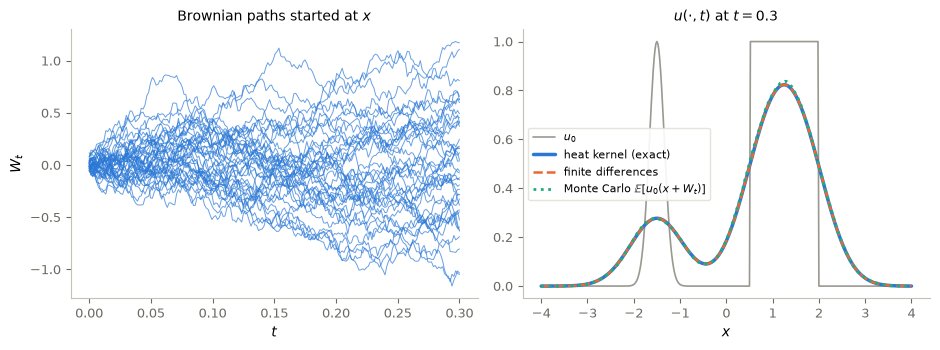

max |FD - exact|          = 1.21e-04
max |Monte Carlo - exact| = 1.57e-02   (M = 8000 paths)


In [ ]:
# The heat equation, solved three ways at t = 0.3
x = np.linspace(-4, 4, 401)
dx = x[1] - x[0]
u0 = lambda z: np.exp(-(z + 1.5) ** 2 / 0.05) + 1.0 * ((z > 0.5) & (z < 2.0))   # bump + step
t_end = 0.3

# (a) exact: convolution with the heat kernel
K = np.exp(-(x[:, None] - x[None, :]) ** 2 / (2 * t_end)) / np.sqrt(2 * np.pi * t_end)
u_exact = K @ u0(x) * dx

# (b) explicit finite differences (stable while dt <= dx^2)
u_fd, dt = u0(x).copy(), 0.4 * dx ** 2
for _ in range(int(t_end / dt)):
    u_fd[1:-1] += 0.5 * dt / dx ** 2 * (u_fd[2:] - 2 * u_fd[1:-1] + u_fd[:-2])

# (c) Feynman-Kac: simulate Brownian paths and average the initial datum at their endpoints
M, n_steps = 8000, 200
paths = np.sqrt(t_end / n_steps) * rng.standard_normal((M, n_steps))
paths = np.cumsum(paths, axis=1)
u_mc = u0(x[:, None] + paths[None, :, -1]).mean(axis=1)

fig, (axL, axR) = P.panels(2, size=(4.75, 3.6))
axL.plot(np.linspace(0, t_end, n_steps), paths[:40].T, lw=0.7, alpha=0.7, color=P.BLUE)
P.label(axL, "$t$", "$W_t$", "Brownian paths started at $x$")
P.curves(axR, x, {"$u_0$": (u0(x), {"color": P.GREY, "lw": 1.2}),
                "heat kernel (exact)": (u_exact, {"color": P.BLUE, "lw": 2.5}),
                "finite differences": (u_fd, {"color": P.ORANGE, "ls": "--", "lw": 1.8}),
                r"Monte Carlo $\mathbb{E}[u_0(x+W_t)]$": (u_mc, {"color": P.AQUA, "ls": ":", "lw": 2.0})},
       xlabel="$x$", title=f"$u(\\cdot, t)$ at $t = {t_end}$")
plt.show()